## 12.04 锚框


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"

torch.set_printoptions(2)  # 精简输出精度


---


### 练习 12.4.1

**题目：** 在`multibox_prior`函数中更改`sizes`和`ratios`的值。生成的锚框有什么变化？

**解答：**

&emsp;&emsp;假设输入图像的高度为$h$，宽度为$w$。以每个像素为中心生成锚框，*缩放比*为$s\in (0, 1]$，*宽高比*为$r > 0$，则锚框的宽度和高度分别是$ws\sqrt{r}$和$hs/\sqrt{r}$。

- `sizes`控制锚框的尺寸：较大的`size`生成更大的锚框，较小的`size`生成更小的锚框；
- `ratios`控制锚框的宽高比：较高的`ratio`生成更窄（高瘦）的锚框，较低的`ratio`生成更宽（扁平）的锚框。

&emsp;&emsp;以同一像素为中心共生成$n+m-1$个锚框（$n$为`size`个数，$m$为`ratio`个数），改变两者会影响锚框在不同尺度和宽高比上的分布，以适应不同大小和形状的目标。

以下使用 `torch` 编程进行验证：


In [6]:
set_figsize()
img = plt.imread('../images/catdog.jpg')
h, w = img.shape[:2]
print(h, w)
X = torch.rand(size=(1, 3, h, w))

# 改变 sizes 与 ratios，比较生成的锚框数量与形状
for sizes, ratios in [([0.75, 0.5, 0.25], [1, 2, 0.5]),
                      ([0.5], [1]),
                      ([0.9, 0.6], [2, 1, 0.5])]:
    Y = multibox_prior(X, sizes=sizes, ratios=ratios)
    bpp = len(sizes) + len(ratios) - 1
    print(f'sizes={sizes}, ratios={ratios} -> 锚框数量 {Y.shape[1]} = {h}x{w}x{bpp}')

561 728
sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5] -> 锚框数量 2042040 = 561x728x5
sizes=[0.5], ratios=[1] -> 锚框数量 408408 = 561x728x1
sizes=[0.9, 0.6], ratios=[2, 1, 0.5] -> 锚框数量 1633632 = 561x728x4


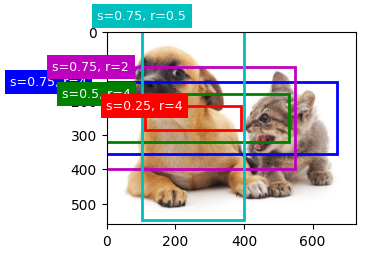

In [7]:
# 可视化：同一像素中心（250, 250）在不同 sizes/ratios 下的锚框
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[4, 2, 0.5])
boxes = Y.reshape(h, w, 5, 4)
bbox_scale = torch.tensor((w, h, w, h))
fig = plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=4', 's=0.5, r=4', 's=0.25, r=4', 's=0.75, r=2', 's=0.75, r=0.5']);

&emsp;&emsp;可以看到，较大的`size`生成更大的锚框；`r=4`的锚框高瘦，`r=0.5`的锚框扁平。

使用 `PyPTO` 编程进行验证（`src/PyPTOAnchor.py` 中的 PyPTO kernel 版本，动态 shape 支持任意 sizes/ratios）：


In [9]:
from src.PyPTOAnchor import multibox_prior as mb_prior_pypto

X_npu = X.to(device)
Y_pt = mb_prior_pypto(X_npu, sizes=[0.75, 0.5, 0.25], ratios=[4, 2, 0.5])
print('PyPTO 锚框形状:', Y_pt.shape)

# 与 torch 版本对比（相同参数下数值应一致）
Y_torch = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[4, 2, 0.5])
print('与 torch 版本一致:', torch.allclose(Y_pt.cpu(), Y_torch, atol=1e-6))

# 更换 sizes/ratios 后无需重编译（动态 shape）
Y2_pt = mb_prior_pypto(X_npu, sizes=[0.5], ratios=[1])
print('sizes=[0.5], ratios=[1] ->', Y2_pt.shape)

PyPTO 锚框形状: torch.Size([1, 2042040, 4])
与 torch 版本一致: True
sizes=[0.5], ratios=[1] -> torch.Size([1, 408408, 4])


---


### 练习 12.4.2

**题目：** 构建并可视化两个IoU为0.5的边界框。它们是怎样重叠的？

**解答：**

&emsp;&emsp;取两个相同尺寸（$4\times 4$）的边界框，令其水平方向重叠部分的宽度为$4/3$：
框1为$[0,0,4,4]$，框2为$[4/3,0,16/3,4]$。交叠面积为$4\times 4/3 = 16/3$，并集面积为$16+16-16/3=80/3$，故IoU$=\frac{16/3}{80/3}=0.5$。

以下使用 `torch` 编程进行验证：


IoU = 0.5000


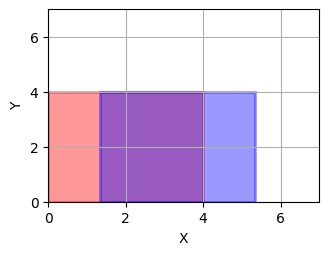

In [12]:
import matplotlib.patches as patches

def plot_boxes(boxes1, boxes2):
    fig, ax = plt.subplots()
    for box in boxes1:
        ax.add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                       linewidth=2, edgecolor='r', facecolor='r', alpha=0.4))
    for box in boxes2:
        ax.add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                       linewidth=2, edgecolor='b', facecolor='b', alpha=0.4))
    ax.set_xlim(0, 7); ax.set_ylim(0, 7)
    ax.set_xticks([0, 2, 4, 6]); ax.set_yticks([0, 2, 4, 6])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.grid(True)

def box_iou_torch(boxes1, boxes2):
    box_area = lambda b: (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    areas1, areas2 = box_area(boxes1), box_area(boxes2)
    inter_ul = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lr = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lr - inter_ul).clamp(min=0)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    return inter_areas / (areas1[:, None] + areas2 - inter_areas)

boxes1 = torch.tensor([[0, 0, 4, 4]])
boxes2 = torch.tensor([[4/3, 0, 16/3, 4]])
plot_boxes(boxes1, boxes2)
iou = box_iou_torch(boxes1, boxes2)
print(f'IoU = {iou.item():.4f}')

&emsp;&emsp;两个边界框水平方向重叠约$1/3$宽度，红色（框1）与蓝色（框2）的交叠区域占各自面积的一半，正是IoU$=0.5$的直观体现。

使用 `PyPTO` 编程进行验证（`src/PyPTOAnchor.py` 的 `box_iou` kernel）：


In [14]:
from src.PyPTOAnchor import box_iou

# PyPTO kernel 要求 FP32 输入
iou_pt = box_iou(boxes1.float().to(device), boxes2.float().to(device))
print(f'PyPTO box_iou = {iou_pt.cpu().item():.4f}')
print('与 torch 一致:', torch.allclose(iou_pt.cpu(), iou, atol=1e-6))

/mnt/workspace/cann-learning-hub_another/contrib/tutorials/d2l_ai_pypto/12_pypto_computer_vision/answers/../src/PyPTOAnchor.py:192: UserWarning: Cannot create tensor with interal format while allow_internel_format=False, tensor will be created with base format. (Triggered internally at ../torch_npu/csrc/aten/common/TensorFactories.cpp:340.)
  boxes1_p = torch.cat([boxes1, torch.zeros_like(boxes1)], dim=1)
PyPTO box_iou = 0.5000
与 torch 一致: True


---


### 练习 12.4.3

**题目：** 在 [12.4.3节](./12.04_anchor.ipynb)和 [12.4.4节](./12.04_anchor.ipynb)中修改变量`anchors`，结果如何变化？

**解答：**

&emsp;&emsp;针对 12.4.3 节的标注算法与 12.4.4 节的预测算法，修改`anchors`的值（例如将5个锚框换成4个更贴合真实框的锚框），可以看到：

- 与真实边界框（狗、猫）IoU最大的锚框被标记为对应类别，其余锚框按阈值（0.5）判定为背景；
- `multibox_detection`输出中，正类锚框给出类别与置信度，负类（背景）锚框类别为-1。

以下使用 `torch` 编程进行验证：


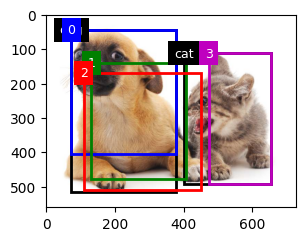

In [17]:
# 读取图像并生成原始锚框
img = plt.imread('../images/catdog.jpg')
h, w = img.shape[:2]
X = torch.rand(size=(1, 3, h, w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
boxes = Y.reshape(h, w, 5, 4)
bbox_scale = torch.tensor((w, h, w, h))
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                             [1, 0.55, 0.2, 0.9, 0.88]])

# 修改后的 anchors（4 个，更贴近真实框）
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.72], [0.18, 0.25, 0.56, 0.85],
                        [0.15, 0.3, 0.62, 0.91], [0.65, 0.2, 0.9, 0.88]])

fig = plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3']);

In [18]:
# 自包含的 torch 实现（d2l 原版，D2LFunction 未包含以下辅助函数）
def assign_anchor_to_bbox_torch(ground_truth, anchors, iou_threshold=0.5):
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    jaccard = box_iou_torch(anchors, ground_truth)
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long, device=anchors.device)
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        if jaccard.numel() == 0:
            break
        max_idx = torch.argmax(jaccard)
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx // num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

def offset_boxes_torch(anchors, assigned_bb, eps=1e-6):
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    return torch.cat([offset_xy, offset_wh], axis=1)

def offset_inverse_torch(anchors, offset_preds):
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    return box_center_to_corner(pred_bbox)

def nms_torch(boxes, scores, iou_threshold):
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1:
            break
        iou = box_iou_torch(boxes[i, :].reshape(-1, 4),
                            boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, dtype=torch.long)

def multibox_target_torch(anchors, labels):
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox_torch(label[:, 1:], anchors)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(1, 4)
        class_labels = torch.zeros(num_anchors, dtype=torch.long, device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        offset = offset_boxes_torch(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    return (torch.stack(batch_offset), torch.stack(batch_mask),
            torch.stack(batch_class_labels))

def multibox_detection_torch(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                             pos_threshold=0.009999999):
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse_torch(anchors, offset_pred)
        keep = nms_torch(predicted_bb, conf, nms_threshold)
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        below_min_idx = conf < pos_threshold
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1), conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

In [19]:
# 标注锚框的分类和偏移量（torch 实现）
labels = multibox_target_torch(anchors.unsqueeze(dim=0), ground_truth.unsqueeze(dim=0))
print('类别标签:', labels[2])

类别标签: tensor([[1, 1, 1, 2]])


tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.72],
         [ 1.00,  0.90,  0.65,  0.20,  0.90,  0.88],
         [ 0.00,  0.80,  0.18,  0.25,  0.56,  0.85],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])


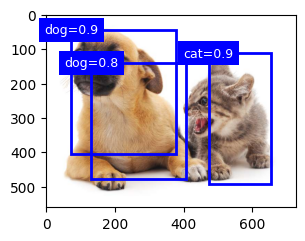

In [20]:
# 修改 anchors 后的预测（multibox_detection, torch 实现）
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,                    # 背景的预测概率
                          [0.9, 0.8, 0.7, 0.1],       # 狗的预测概率
                          [0.1, 0.2, 0.3, 0.9]])      # 猫的预测概率

output = multibox_detection_torch(cls_probs.unsqueeze(dim=0),
                                  offset_preds.unsqueeze(dim=0),
                                  anchors.unsqueeze(dim=0),
                                  nms_threshold=0.5)
print(output)
fig = plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label);

&emsp;&emsp;从结果可以看出，修改`anchors`后：第0框与狗的真实边界框IoU最大，被标记为狗；第3框被标记为猫；第2框与狗的真实边界框IoU超过阈值0.5，也被标记为狗；第1框与各真实框的IoU均低于阈值，被标记为背景。预测阶段经非极大值抑制后，保留置信度最高的框并抑制与其高度重叠的框。

使用 `PyPTO` 编程进行验证（`src/PyPTOAnchor.py` 的 kernel 版本）：


In [22]:
from src.PyPTOAnchor import multibox_target, multibox_detection

anchors_pt = anchors.float().unsqueeze(0).to(device)
gt_pt = ground_truth.float().unsqueeze(0).to(device)
labels_pt = multibox_target(anchors_pt, gt_pt)
print('PyPTO 类别标签:', labels_pt[2])
print('与 torch 一致:', torch.equal(labels_pt[2].cpu().long(), labels[2]))

PyPTO 类别标签: tensor([[1, 1, 1, 2]], device='npu:1', dtype=torch.int32)
与 torch 一致: True


In [23]:
cls_probs_pt = cls_probs.float().unsqueeze(0).to(device)
offset_preds_pt = offset_preds.float().unsqueeze(0).to(device)
output_pt = multibox_detection(cls_probs_pt, offset_preds_pt, anchors_pt, nms_threshold=0.5)
print('PyPTO 预测结果:')
print(output_pt)
print('与 torch 一致:', torch.allclose(output_pt.cpu(), output, atol=1e-6))

PyPTO 预测结果:
tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.72],
         [ 1.00,  0.90,  0.65,  0.20,  0.90,  0.88],
         [ 0.00,  0.80,  0.18,  0.25,  0.56,  0.85],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]], device='npu:1')
与 torch 一致: True


---


### 练习 12.4.4

**题目：** 非极大值抑制是一种贪心算法，它通过*移除*来抑制预测的边界框。是否存在一种可能，被移除的一些框实际上是有用的？如何修改这个算法来柔和地抑制？可以参考Soft-NMS。

**解答：**

&emsp;&emsp;确实存在被移除的框实际上有用的可能。例如在目标密集的场景中，两个高度重叠的框可能代表不同的目标实例，硬NMS（Hard-NMS）会直接移除与高置信度框重叠超过阈值的框，导致漏检（missed detections）。

&emsp;&emsp;**Soft-NMS**的思路是：不再直接移除重叠框，而是通过衰减函数*降低*与高置信度框重叠的其他框的置信度，重叠越大、衰减越狠，但仍保留其参与后续筛选的机会。高斯衰减版本为：
$$s_i = s_i \cdot e^{-\frac{\text{IoU}(M, b_i)^2}{\sigma}}$$
其中$M$为当前置信度最高的框，$b_i$为其余框，$\sigma$控制衰减强度。

以下使用 `torch` 编程进行验证（高斯Soft-NMS vs 硬NMS）：


In [26]:
def soft_nms(boxes, scores, sigma=0.5, score_threshold=1e-4):
    """高斯 Soft-NMS：返回保留框的索引（被抑制的框置信度被衰减而非移除）"""
    order = torch.argsort(scores, descending=True)
    boxes, scores = boxes[order].clone(), scores[order].clone()
    keep = []
    for i in range(boxes.shape[0]):
        if scores[i] <= score_threshold:
            continue
        keep.append(order[i].item())
        if i == boxes.shape[0] - 1:
            break
        ious = box_iou_torch(boxes[i:i+1], boxes[i+1:])[0]
        scores[i+1:] *= torch.exp(-ious ** 2 / sigma)
        # 按衰减后的分数重新排序
        sub = torch.argsort(scores[i+1:], descending=True) + (i + 1)
        boxes[i+1:] = boxes[sub]; scores[i+1:] = scores[sub]
    return torch.tensor(keep, dtype=torch.long)

# 构造两个高度重叠的框：真实有两个目标，但预测框几乎重合
b1 = torch.tensor([[10., 10., 50., 50.], [12., 12., 52., 52.]])
s1 = torch.tensor([0.95, 0.90])
print('两个框的IoU:', box_iou_torch(b1, b1)[0, 1].item())

# 硬NMS：直接移除第二个框
def hard_nms(boxes, scores, iou_threshold=0.5):
    order = torch.argsort(scores, descending=True)
    keep = []
    while order.numel() > 0:
        i = order[0]; keep.append(i)
        if order.numel() == 1:
            break
        ious = box_iou_torch(boxes[i:i+1], boxes[order[1:]])[0]
        order = order[1:][ious <= iou_threshold]
    return torch.tensor(keep, dtype=torch.long)

print('硬NMS保留:', hard_nms(b1, s1).tolist(), '  (框1被移除)')
keep = soft_nms(b1, s1)
print('Soft-NMS保留:', keep.tolist(), '  (两个框都保留，但低置信度框分数被衰减)')

两个框的IoU: 0.8223234415054321
硬NMS保留: [0]   (框1被移除)
Soft-NMS保留: [0, 1]   (两个框都保留，但低置信度框分数被衰减)


---


### 练习 12.4.5

**题目：** 如果非手动，非最大限度的抑制可以被学习吗？

**解答：**

&emsp;&emsp;可以。传统NMS是手动设计的算法，使用固定阈值和规则抑制冗余边界框；而可学习的NMS将其形式化为可通过反向传播优化的模块，常见做法有：

1. **端到端（End-to-End）方法**：将NMS作为模块嵌入目标检测网络，在网络输出中除类别与边界框外，增加一个分支预测每个边界框的抑制得分，通过网络端到端训练学习保留或抑制的策略；
2. **两阶段（Two-Stage）方法**：第一阶段用候选框生成网络产生大量候选框，第二阶段训练一个辅助网络学习NMS策略，从候选框中选择最优边界框。

&emsp;&emsp;这些方法把NMS问题转化为可微的学习任务，能够根据任务与数据集特点自适应地选择保留或抑制边界框，从而提升密集场景下的检测性能；代价是需要更多训练数据与计算资源。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
